In [21]:
import sys
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [14]:
from pathlib import Path

DATA_DIR = Path.cwd().parent / "data" / "raw" / "archive" / "classification"
IMAGE_DIR = DATA_DIR / "images"
LABELS_FILE = DATA_DIR / "labels.csv"

print("Images exist:", IMAGE_DIR.exists())
print("Labels exist:", LABELS_FILE.exists())

Images exist: True
Labels exist: True


In [5]:
image_paths = sorted(IMAGE_DIR.glob("*.jpg"))

print("Number of JPG images:", len(image_paths))
print("First five images:")

for path in image_paths[:5]:
    print(path.name)

Number of JPG images: 2227
First five images:
image_1.jpg
image_10.jpg
image_100.jpg
image_1000.jpg
image_1001.jpg


In [15]:
labels_df = pd.read_csv(LABELS_FILE)

print("Dataset shape:", labels_df.shape)
display(labels_df.head())

Dataset shape: (2227, 6)


,original_file_name,file_name,Surface_Crack,Delamination,Pinhole,unclassified
0,R7-700um-middle_frame_489_patch_1.png,image_1.jpg,1,0,0,0
1,R1-1100um-top-to-bottom-center-1_frame_220_pat...,image_2.jpg,1,0,0,0
2,R1-1100um-top-to-bottom-center_frame_85_patch_...,image_3.jpg,1,0,1,0
3,R1-1100um-top-to-bottom-center-1_frame_190_pat...,image_4.jpg,0,0,1,0
4,R1-1100um-top-to-bottom-center_frame_218_patch...,image_5.jpg,1,0,0,0


In [7]:
print(labels_df.columns.tolist())

['original_file_name', 'file_name', 'Surface_Crack', 'Delamination', 'Pinhole', 'unclassified']


In [9]:
defect_columns = [
    "Surface_Crack",
    "Delamination",
    "Pinhole",
    "unclassified",
]

print(labels_df[defect_columns].dtypes)
print(labels_df[defect_columns].sum())

Surface_Crack    int64
Delamination     int64
Pinhole          int64
unclassified     int64
dtype: object
Surface_Crack    1947
Delamination      203
Pinhole           519
unclassified       78
dtype: int64


In [10]:
labels_df["number_of_labels"] = labels_df[defect_columns].sum(axis=1)

print(labels_df["number_of_labels"].value_counts().sort_index())

number_of_labels
0      44
1    1657
2     488
3      38
Name: count, dtype: int64


In [11]:
single_label_df = labels_df[
    labels_df["number_of_labels"] == 1
].copy()

print("Single-label images:", len(single_label_df))

Single-label images: 1657


I only use the images that have one single defect

In [12]:
single_label_df["class_name"] = (
    single_label_df[defect_columns]
    .idxmax(axis=1)
)

print(single_label_df["class_name"].value_counts())

class_name
Surface_Crack    1430
Pinhole           169
unclassified       37
Delamination       21
Name: count, dtype: int64


remove the unclassified ones

In [13]:
model_df = single_label_df[
    single_label_df["class_name"] != "unclassified"
].copy()

print(model_df["class_name"].value_counts())

class_name
Surface_Crack    1430
Pinhole           169
Delamination       21
Name: count, dtype: int64


In [16]:
class_counts = model_df["class_name"].value_counts()

summary = pd.DataFrame({
    "count": class_counts,
    "percentage": (class_counts / len(model_df) * 100).round(2)
})

summary

,count,percentage
class_name,,
Surface_Crack,1430,88.27
Pinhole,169,10.43
Delamination,21,1.30


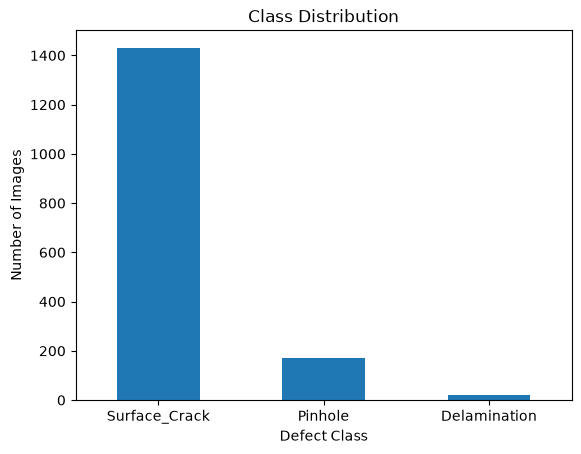

In [19]:
class_counts.plot(
    kind="bar",
    title="Class Distribution",
    xlabel="Defect Class",
    ylabel="Number of Images"
)

plt.xticks(rotation=0)
plt.show()

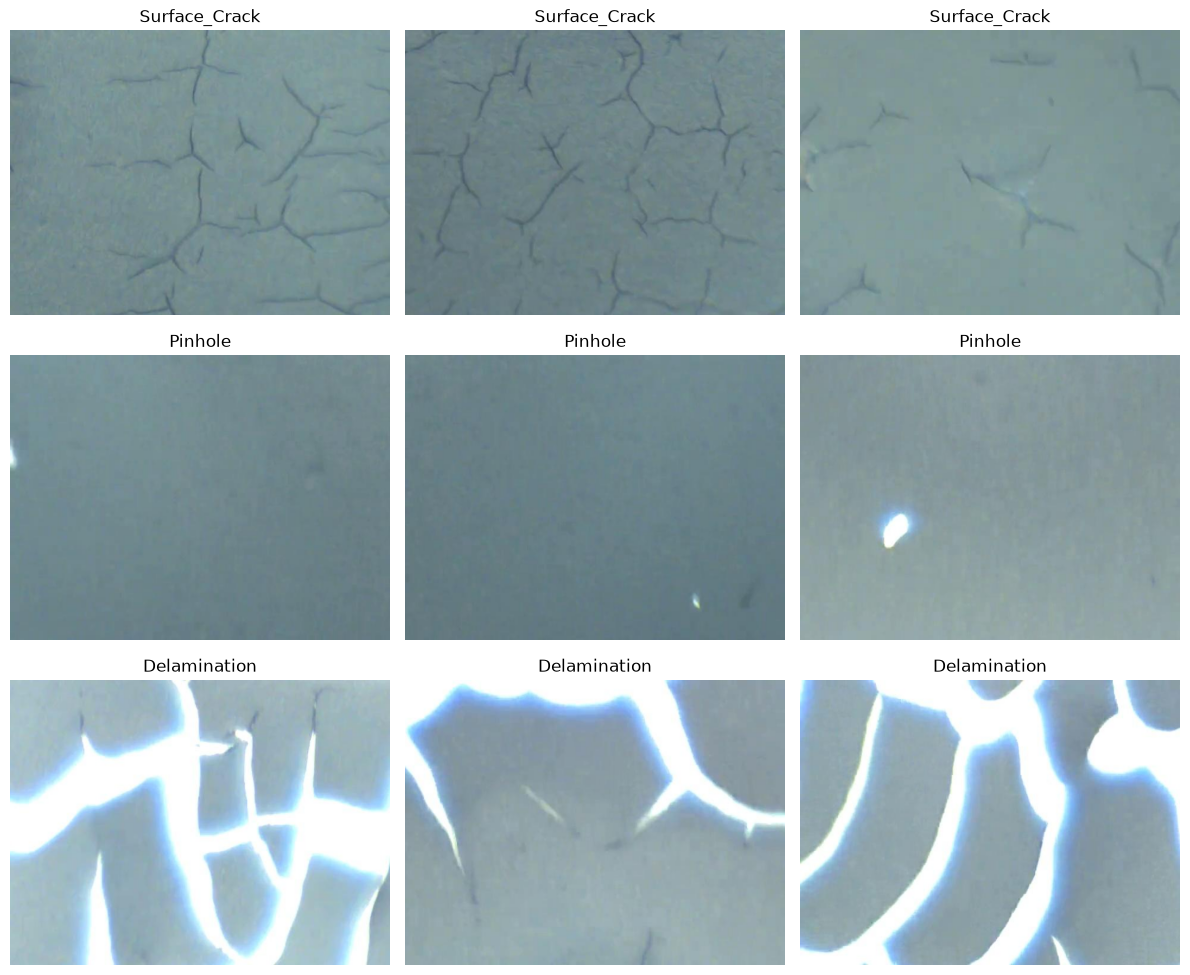

In [22]:
classes = ["Surface_Crack", "Pinhole", "Delamination"]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for row, class_name in enumerate(classes):
    samples = model_df[
        model_df["class_name"] == class_name
    ].sample(3, random_state=42)

    for col, (_, sample) in enumerate(samples.iterrows()):
        image = Image.open(
            IMAGE_DIR / sample["file_name"]
        )

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [23]:
print("Total images:", len(model_df))
print(
    "Unique original files:",
    model_df["original_file_name"].nunique()
)

Total images: 1620
Unique original files: 1620


In [24]:
model_df["original_file_name"].value_counts().head(10)

original_file_name
R7-700um-middle_frame_489_patch_1.png                     1
R1-1100um-top-to-bottom-center-1_frame_220_patch_7.png    1
R1-1100um-top-to-bottom-center-1_frame_190_patch_0.png    1
R1-1100um-top-to-bottom-center_frame_218_patch_5.png      1
R1-1100um-top-to-bottom-center_frame_77_patch_1.png       1
R1-700um-top-to-bottom-center_frame_597_patch_3.png       1
R7-700um-middle_frame_100_patch_5.png                     1
R1-900um-top-to-bottom-center_frame_251_patch_2.png       1
R1-900um-top-to-bottom-center_frame_512_patch_1.png       1
R1-1000um-top-to-bottom-center_frame_173_patch_1.png      1
Name: count, dtype: int64

In [ ]:
processed_dir = Path.cwd().parent / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

model_df.to_csv(
    processed_dir / "model_metadata.csv",
    index=False
)

print("Saved model_metadata.csv")